In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [24]:
PCAWG = '../out/PCAWG_fit.tsv'
sample = '../out/sample_fitness.tsv'
use_sample = False

data = pd.read_csv(PCAWG if use_sample else sample, sep='\t', index_col=0)
data["TsgOg"] = data["Tsg"] + data["Og"]
columns = ["Fitness", "Stress", "Essentiality", "Tsg", "Og", "TsgOg"]
data.head()


FileNotFoundError: [Errno 2] No such file or directory: '../out/sample_fitness.tsv'

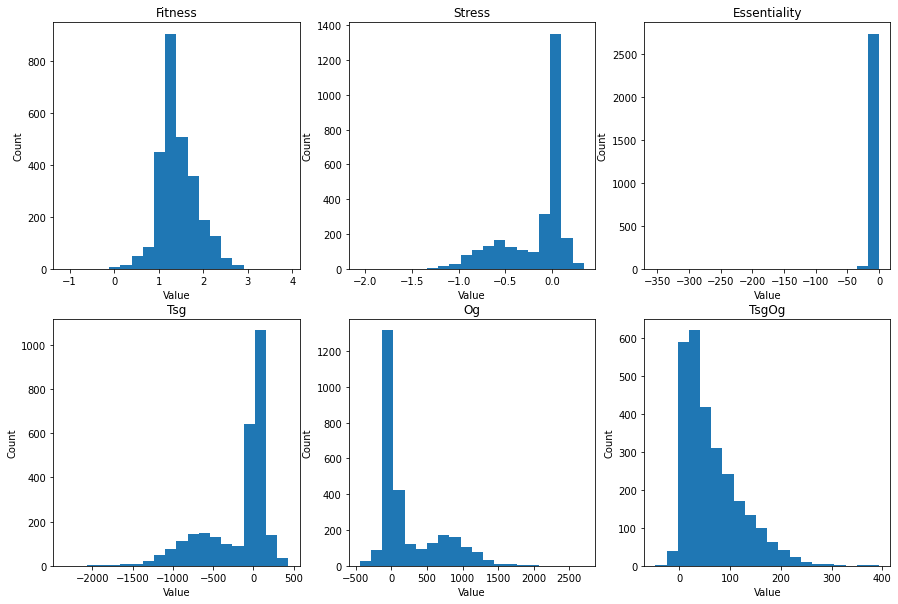

In [ ]:
bin_count = 50 if use_sample else 20

# create 6 subplots 2*3
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# plot the data
for x in range(2):
    for y in range(3):
        axes[x, y].set_xlabel('Value')
        axes[x, y].set_ylabel('Count')
        axes[x, y].set_title(columns[x*3+y])    
        axes[x, y].hist(data[columns[x*3+y]], bins=bin_count)

In [23]:
data["Essentiality"].min()
# data where essentiality is min
data[data["Essentiality"] == data["Essentiality"].min()]

,Fitness,Stress,Tsg,Og,Essentiality,TsgOg
Id,,,,,,
931b24da-5d6d-4c2d-8de9-ef32d6eb8565,-1.1145,0.1963,340.7458,-218.5155,-353.3065,122.2303


Text(0.5, 0, '$\\Delta(F)$')

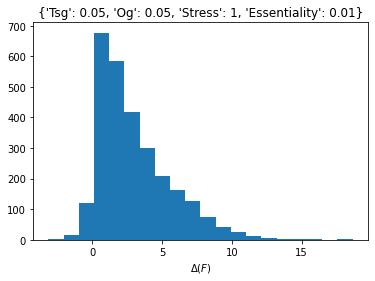

In [10]:
params =  {"Tsg": 0.05, "Og": 0.05, "Stress": 1, "Essentiality": 0.01 }
myfun = lambda x : (params[x] * data[x]).to_numpy()
mySum = sum(map(myfun, params.keys()))
plt.title(f"{params}")
plt.hist(mySum, bins=bin_count);
plt.xlabel('$\Delta(F)$')

Text(0, 0.5, 'Og')

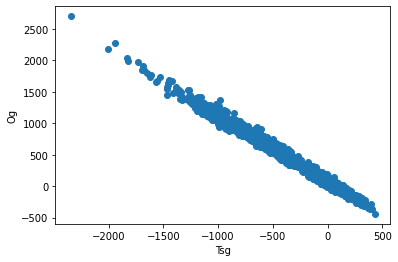

In [11]:
plt.scatter(data["Tsg"], data["Og"]);
plt.xlabel("Tsg")
plt.ylabel("Og")

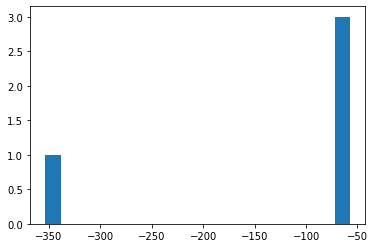

In [12]:
plt.hist(data["Essentiality"][data["Essentiality"] < -50], bins=bin_count);

(array([ 93., 244., 804., 383., 147.,  60.,  46.,  24.,  16.,   8.]),
 array([-0.0982 , -0.05447, -0.01074,  0.03299,  0.07672,  0.12045,
         0.16418,  0.20791,  0.25164,  0.29537,  0.3391 ]),
 <BarContainer object of 10 artists>)

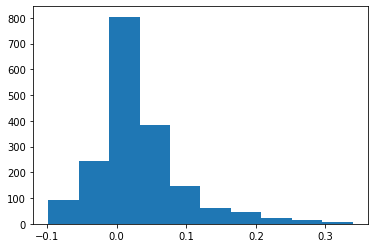

In [13]:
plt.hist(data["Stress"][data["Stress"] > -0.1])

In [9]:
data["Stress"][data["Stress"] >= 0].min()

0.0

In [10]:
data["Stress"][data["Stress"] == 0]

Id
0-0       0.0
3583-1    0.0
7237-1    0.0
7735-1    0.0
Name: Stress, dtype: float64

In [11]:
data.loc["16c6f975-48fd-4cda-946a-777cb922949d"]

KeyError: '16c6f975-48fd-4cda-946a-777cb922949d'

In [ ]:
data["Essentiality"][data["Essentiality"] < -300]

Id
931b24da-5d6d-4c2d-8de9-ef32d6eb8565   -332.6031
Name: Essentiality, dtype: float64